In [1]:
!pip install scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv('Advertising.csv')

# Show first 10 rows
print("First 10 rows:")
df.head(10)

First 10 rows:


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [4]:
# Shape of dataset
print("Shape:", df.shape)

# Column info
print("\nDataset Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Missing values check
print("\nMissing Values:")
print(df.isnull().sum())

print("\n✅ No missing values — clean dataset!")

Shape: (200, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Statistical Summary:
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.5250

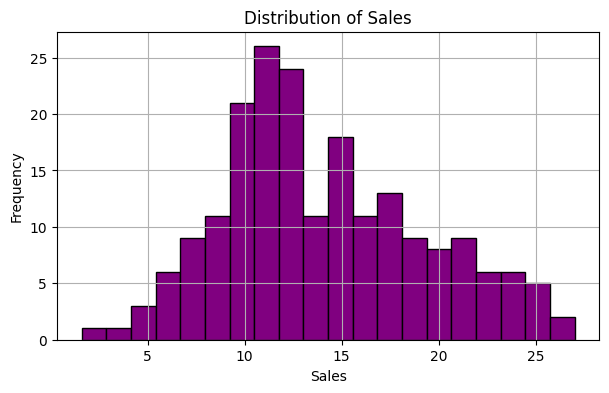

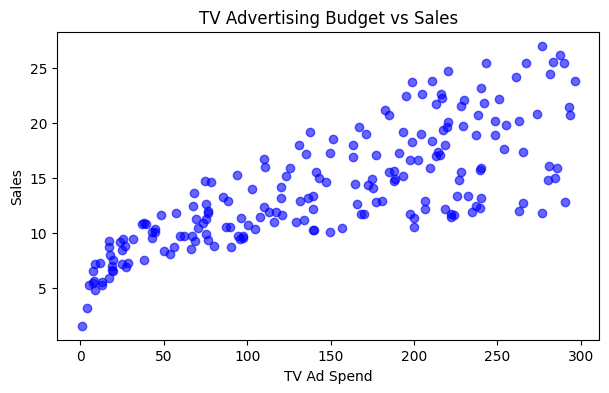

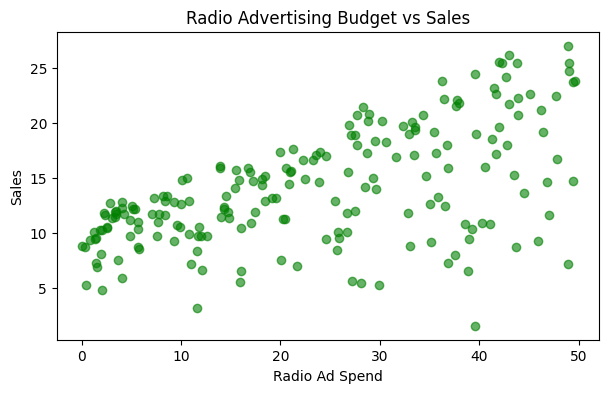

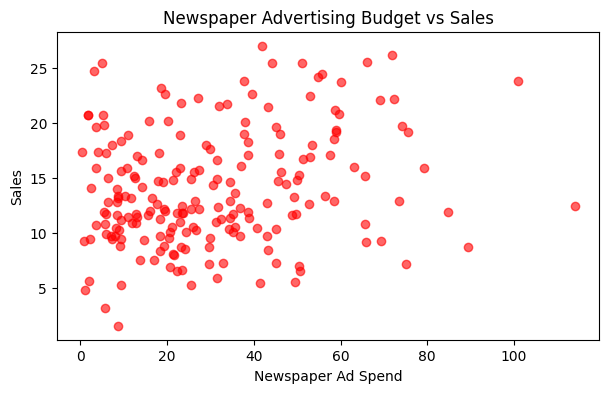

In [5]:
# Chart 1: Distribution of Sales
plt.figure(figsize=(7,4))
df['Sales'].hist(bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# Chart 2: TV Ads vs Sales
plt.figure(figsize=(7,4))
plt.scatter(df['TV'], df['Sales'],
            color='blue', alpha=0.6)
plt.title('TV Advertising Budget vs Sales')
plt.xlabel('TV Ad Spend')
plt.ylabel('Sales')
plt.show()

# Chart 3: Radio Ads vs Sales
plt.figure(figsize=(7,4))
plt.scatter(df['Radio'], df['Sales'],
            color='green', alpha=0.6)
plt.title('Radio Advertising Budget vs Sales')
plt.xlabel('Radio Ad Spend')
plt.ylabel('Sales')
plt.show()

# Chart 4: Newspaper Ads vs Sales
plt.figure(figsize=(7,4))
plt.scatter(df['Newspaper'], df['Sales'],
            color='red', alpha=0.6)
plt.title('Newspaper Advertising Budget vs Sales')
plt.xlabel('Newspaper Ad Spend')
plt.ylabel('Sales')
plt.show()

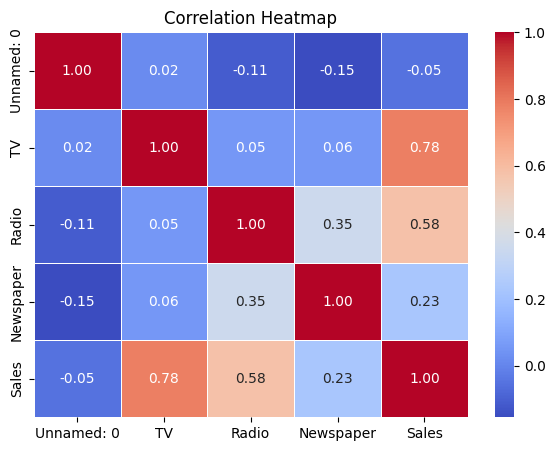

💡 Higher value = stronger relationship with Sales


In [6]:
# How related are the features to each other?
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

print("💡 Higher value = stronger relationship with Sales")

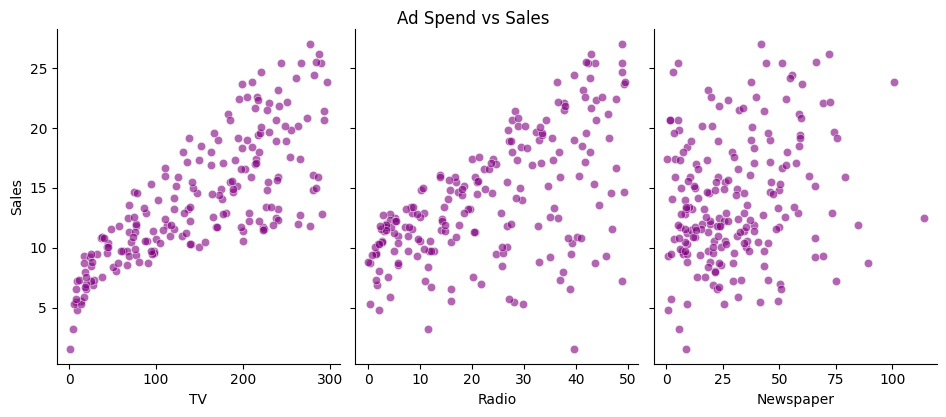

In [7]:
# See all relationships at once
sns.pairplot(df,
             x_vars=['TV', 'Radio', 'Newspaper'],
             y_vars=['Sales'],
             height=4,
             aspect=0.8,
             kind='scatter',
             plot_kws={'alpha': 0.6, 'color': 'purple'})
plt.suptitle('Ad Spend vs Sales', y=1.02)
plt.show()

In [8]:
# Features (X) = TV, Radio, Newspaper spending
# Target (y) = Sales

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("\nFeatures used:")
print("  - TV Ad Spend")
print("  - Radio Ad Spend")
print("  - Newspaper Ad Spend")
print("\n✅ Data ready!")

Features shape: (200, 3)
Target shape  : (200,)

Features used:
  - TV Ad Spend
  - Radio Ad Spend
  - Newspaper Ad Spend

✅ Data ready!


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Total samples  :", len(df))
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("✅ Split done!")

Total samples  : 200
Training samples: 160
Testing samples : 40
✅ Split done!


In [10]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("📊 Linear Regression Results:")
print(f"   MAE  : {lr_mae:.3f}")
print(f"   RMSE : {lr_rmse:.3f}")
print(f"   R²   : {lr_r2:.3f}")

# Show coefficients
coef_df = pd.DataFrame({
    'Feature': ['TV', 'Radio', 'Newspaper'],
    'Coefficient': lr_model.coef_
})
print("\n📋 Feature Coefficients:")
print(coef_df)
print("\n💡 Higher coefficient = more impact on Sales")

📊 Linear Regression Results:
   MAE  : 1.461
   RMSE : 1.782
   R²   : 0.899

📋 Feature Coefficients:
     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761

💡 Higher coefficient = more impact on Sales


In [11]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("📊 Random Forest Results:")
print(f"   MAE  : {rf_mae:.3f}")
print(f"   RMSE : {rf_rmse:.3f}")
print(f"   R²   : {rf_r2:.3f}")

📊 Random Forest Results:
   MAE  : 0.620
   RMSE : 0.769
   R²   : 0.981


In [12]:
# Train Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# Evaluate
gb_mae  = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2   = r2_score(y_test, gb_pred)

print("📊 Gradient Boosting Results:")
print(f"   MAE  : {gb_mae:.3f}")
print(f"   RMSE : {gb_rmse:.3f}")
print(f"   R²   : {gb_r2:.3f}")

📊 Gradient Boosting Results:
   MAE  : 0.619
   RMSE : 0.730
   R²   : 0.983


           MODEL COMPARISON TABLE
            Model      MAE     RMSE       R²
Linear Regression 1.460757 1.781600 0.899438
    Random Forest 0.620100 0.768591 0.981284
Gradient Boosting 0.618742 0.729782 0.983127
💡 Lower MAE/RMSE = Better | Higher R² = Better


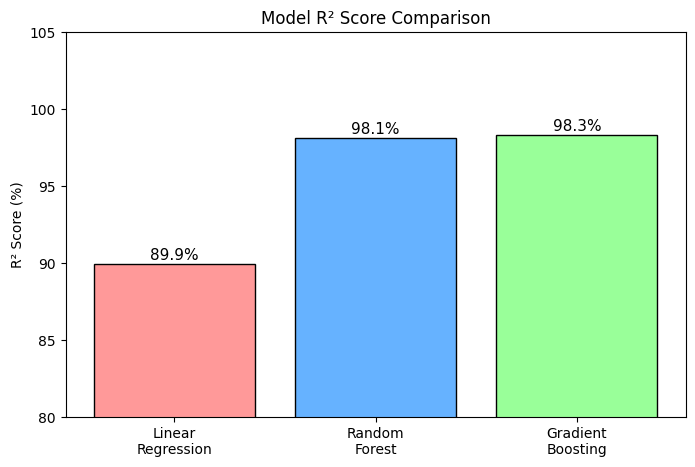

In [13]:
# Comparison Table
comparison = pd.DataFrame({
    'Model': ['Linear Regression',
              'Random Forest',
              'Gradient Boosting'],
    'MAE' : [lr_mae,  rf_mae,  gb_mae],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse],
    'R²'  : [lr_r2,   rf_r2,   gb_r2]
})

print("=" * 55)
print("           MODEL COMPARISON TABLE")
print("=" * 55)
print(comparison.to_string(index=False))
print("=" * 55)
print("💡 Lower MAE/RMSE = Better | Higher R² = Better")

# Bar chart comparison
plt.figure(figsize=(8,5))
bars = plt.bar(
    ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting'],
    [lr_r2*100, rf_r2*100, gb_r2*100],
    color=['#FF9999', '#66B2FF', '#99FF99'],
    edgecolor='black'
)
for bar, r2 in zip(bars, [lr_r2, rf_r2, gb_r2]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{r2*100:.1f}%',
             ha='center', fontsize=11)
plt.ylim(80, 105)
plt.title('Model R² Score Comparison')
plt.ylabel('R² Score (%)')
plt.show()

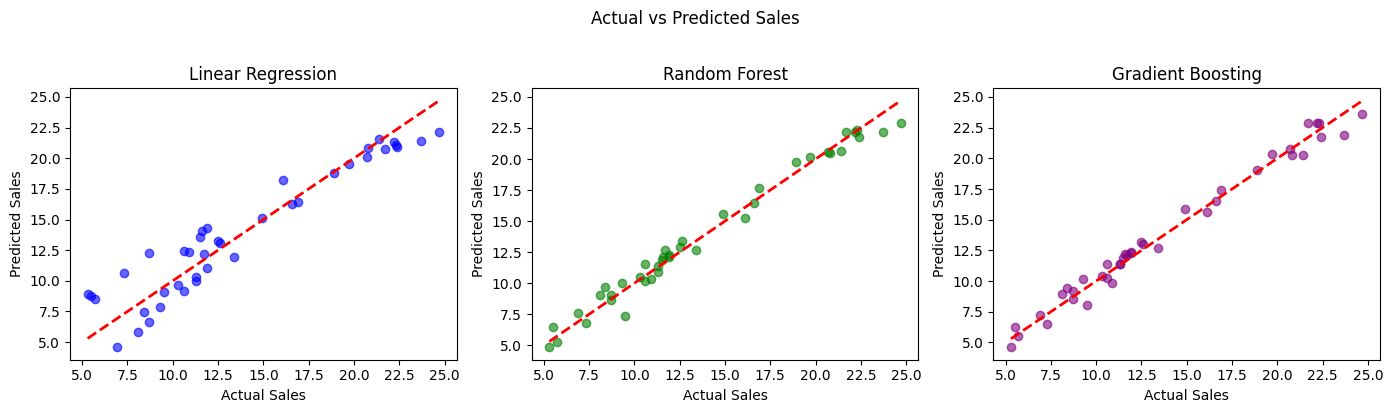

✅ Closer to red line = better predictions!


In [14]:
plt.figure(figsize=(14,4))

# Linear Regression
plt.subplot(1,3,1)
plt.scatter(y_test, lr_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

# Random Forest
plt.subplot(1,3,2)
plt.scatter(y_test, rf_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

# Gradient Boosting
plt.subplot(1,3,3)
plt.scatter(y_test, gb_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Gradient Boosting')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.suptitle('Actual vs Predicted Sales', y=1.02)
plt.tight_layout()
plt.show()

print("✅ Closer to red line = better predictions!")

/tmp/ipykernel_1440/3868600983.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


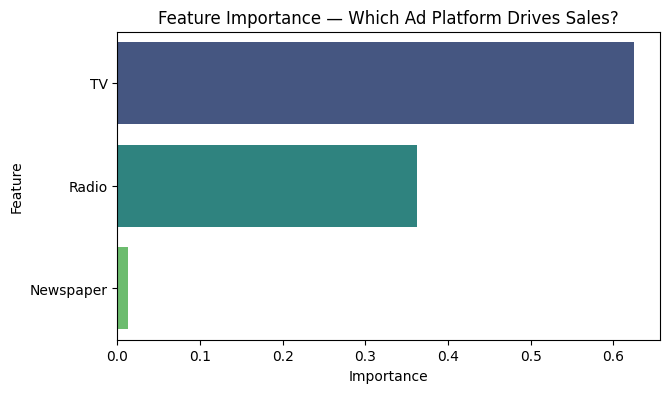

     Feature  Importance
0         TV    0.624810
1      Radio    0.362201
2  Newspaper    0.012989

💡 Invest more in the platform with highest importance!


In [15]:
# Which ad platform affects sales the most?
feature_names = ['TV', 'Radio', 'Newspaper']

importance = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x='Importance', y='Feature',
            data=importance, palette='viridis')
plt.title('Feature Importance — Which Ad Platform Drives Sales?')
plt.show()

print(importance)
print("\n💡 Invest more in the platform with highest importance!")

In [16]:
# Predict sales for different advertising budgets
# Format: [TV_budget, Radio_budget, Newspaper_budget]

print("=" * 50)
print("      SALES PREDICTIONS FOR NEW BUDGETS")
print("=" * 50)

budgets = [
    [230.1, 37.8, 69.2],   # High TV budget
    [44.5,  39.3, 45.1],   # Balanced budget
    [17.2,  45.9, 69.3],   # High Radio budget
    [250.0, 50.0, 30.0],   # Very high TV + Radio
]

budget_names = [
    "High TV Budget      ",
    "Balanced Budget     ",
    "High Radio Budget   ",
    "High TV+Radio Budget",
]

for name, budget in zip(budget_names, budgets):
    new_data = pd.DataFrame([budget],
                             columns=['TV','Radio','Newspaper'])
    prediction = gb_model.predict(new_data)
    print(f"{name} → Predicted Sales: {prediction[0]:.2f}")

print("=" * 50)

      SALES PREDICTIONS FOR NEW BUDGETS
High TV Budget       → Predicted Sales: 22.05
Balanced Budget      → Predicted Sales: 10.70
High Radio Budget    → Predicted Sales: 9.19
High TV+Radio Budget → Predicted Sales: 25.46


In [17]:
print("=" * 55)
print("         💼 BUSINESS INSIGHTS")
print("=" * 55)

# Which platform has highest correlation with sales
correlations = df.corr()['Sales'].drop('Sales')
best_platform = correlations.idxmax()

print(f"\n📺 Correlation with Sales:")
for col in ['TV', 'Radio', 'Newspaper']:
    print(f"   {col:12}: {correlations[col]:.3f}")

print(f"\n🏆 Best advertising platform: {best_platform}")
print(f"\n💡 Recommendations:")
print(f"   1. Invest most budget in {best_platform} advertising")
print(f"   2. Radio also shows good correlation with sales")
print(f"   3. Newspaper has the least impact on sales")
print("=" * 55)

         💼 BUSINESS INSIGHTS

📺 Correlation with Sales:
   TV          : 0.782
   Radio       : 0.576
   Newspaper   : 0.228

🏆 Best advertising platform: TV

💡 Recommendations:
   1. Invest most budget in TV advertising
   2. Radio also shows good correlation with sales
   3. Newspaper has the least impact on sales


In [18]:
print("=" * 55)
print("          TASK 4 — FINAL SUMMARY")
print("=" * 55)
print(f"Dataset       : Advertising Dataset")
print(f"Total Samples : {len(df)}")
print(f"Features Used : TV, Radio, Newspaper Ad Spend")
print(f"Target        : Sales")
print(f"Models Tried  : 3")
print("=" * 55)
print(f"Linear Regression R² : {lr_r2*100:.2f}%")
print(f"Random Forest R²     : {rf_r2*100:.2f}%")
print(f"Gradient Boosting R² : {gb_r2*100:.2f}%")
print("=" * 55)
best = max(lr_r2, rf_r2, gb_r2)*100
print(f"🏆 Best R² Score: {best:.2f}%")
print("=" * 55)

          TASK 4 — FINAL SUMMARY
Dataset       : Advertising Dataset
Total Samples : 200
Features Used : TV, Radio, Newspaper Ad Spend
Target        : Sales
Models Tried  : 3
Linear Regression R² : 89.94%
Random Forest R²     : 98.13%
Gradient Boosting R² : 98.31%
🏆 Best R² Score: 98.31%
